# Window dependence of the mean central mode count
Fixed $N_x=20$, $N_y=32$, all 100 hard-wall pure-state endpoints at cycle 64. Scan the symmetric spectral window $[-L,L]$, average all 32 periodic origins within each trajectory, then average trajectories. Fit subsystem widths $A_y=8,\ldots,16$. This notebook reads the validated cached spectra; no diagonalization or circuit simulation is needed.

In [1]:
import os
if 'AVAILABLE_CPUS' not in globals():AVAILABLE_CPUS=sorted(os.sched_getaffinity(0))
CPU_RANGE=(8,15) # editable inclusive range
selected=list(range(CPU_RANGE[0],CPU_RANGE[1]+1))
assert set(selected).issubset(AVAILABLE_CPUS)
os.sched_setaffinity(0,selected)
for key in ('OPENBLAS_NUM_THREADS','MKL_NUM_THREADS','OMP_NUM_THREADS'):os.environ[key]=str(len(selected))
from threadpoolctl import threadpool_limits
limits=threadpool_limits(len(selected))
print('Allocated CPUs:',selected)

Allocated CPUs: [8, 9, 10, 11, 12, 13, 14, 15]


## Estimator and fit
For each trajectory $s$ and origin $y_0$, use eigenvalues $\lambda_{s,y_0,j}$ of $Q_A=2G_A-\mathbf{1}_A$, where $G_A=F_AF_A^\dagger$ is the restricted occupation correlation matrix. Define
$$N_{s,L}(A_y)=\frac1{32}\sum_{y_0=0}^{31}\sum_j\mathbf{1}_{|\lambda_{s,y_0,j}|\le L},\qquad\overline N_L=\frac1{100}\sum_s N_{s,L}.$$
This is a mean number of modes, with no division by the number of retained modes and no unit-area density normalization. Every x and both orbitals are included; periodic y cuts use $i=40y+2x+\mu$. All default windows are strictly inside $(-1,1)$, so no near-pure-mode cutoff or eigenvalue clipping is needed.

Fit $\overline N_L=a(L)+b(L)\log d$, with $d=(32/\pi)\sin(\pi A_y/32)$ and natural logarithm, using ordinary least squares over widths 8–16. The linear fit operator is applied to each trajectory's origin-averaged curve; coefficient means give the ensemble fit and coefficient SEMs retain all cross-width correlations. The same trajectories contribute to every L, so the fitted coefficients at different windows are also correlated; their joint covariance is exported. R-squared and residual RMS describe the mean curve and are not formal goodness-of-fit probabilities. A sharp counting window can produce level-crossing features.

## Editable configuration and input provenance

In [2]:
from pathlib import Path
import json,hashlib,subprocess
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display,Image
OUT=Path.cwd()
if not (OUT/'build_notebook.py').exists():
    root=next(p for p in (OUT,*OUT.parents) if (p/'PROJECT_ADMIN/REPO_POLICY.md').exists())
    OUT=root/'00_WORKSPACE/CURRENT/final_production_new_designs/09_pure_tangent_replay_acquisition/analysis_outputs/mean_mode_count_window_scan_n20x32_v1'
SOURCE=OUT.parent/'centered_spectral_window_origin_averaged_n20x32_hard_alpha1_v2'
L_VALUES=np.array([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99]) # editable, strictly between 0 and 1
FIT_WIDTHS=(8,16) # inclusive
DISPLAY_WINDOWS=[0.2,0.5,0.8]
assert np.all((L_VALUES>0)&(L_VALUES<1)) and np.all(np.diff(L_VALUES)>0)
def sha(path):
    h=hashlib.sha256()
    with path.open('rb') as f:
        for b in iter(lambda:f.read(8*1024*1024),b''):h.update(b)
    return h.hexdigest()
spectral_diagnostics=json.loads((SOURCE/'spectra_diagnostics.json').read_text())
cache=SOURCE/'subsystem_spectra.npz'
assert sha(cache)==spectral_diagnostics['cache_sha256']
ids=[]
for item in tqdm(spectral_diagnostics['inputs'],desc='Verify production inputs',unit='batch'):
    path=Path(item['path']);r=item['receipt']
    assert json.loads(path.with_suffix('.complete.json').read_text())==r
    assert r['status']=='complete' and path.stat().st_size==r['result_bytes'] and sha(path)==r['result_sha256']
    assert r['configuration_sha256']==spectral_diagnostics['identity']['configuration_sha256']
    ids.extend(r['case_sample_indices'])
assert sorted(ids)==list(range(100))
with np.load(cache) as z:
    sample_ids=z['sample_ids'];origins=z['origins'];widths=z['widths']
assert np.array_equal(sample_ids,np.arange(100)) and np.array_equal(origins,np.arange(32))
assert np.array_equal(widths,np.arange(1,17))
config=dict(Nx=20,Ny=32,samples=100,origins=32,cycle=64,alpha_1=1,alpha_2=30,nshell=1,construction='hard',
 initialization='pure; exterior product frame',sequence='raster_y',windows=L_VALUES.tolist(),fit_widths=list(FIT_WIDTHS),
 canonical_dynamics_entry_point='classA_U1FGTN_gpu.run_markov_circuit (saved inputs only)',
 estimator='mean over origins inside each trajectory, then mean over trajectories; no normalization by mode count',
 spectrum_cache=str(cache),spectrum_cache_sha256=spectral_diagnostics['cache_sha256'],output=str(OUT))
print(json.dumps(config,indent=2))
(OUT/'input_provenance.json').write_text(json.dumps(dict(configuration=config,spectra_diagnostics=spectral_diagnostics),indent=2)+'\n')

Verify production inputs:   0%|          | 0/4 [00:00<?, ?batch/s]

{
  "Nx": 20,
  "Ny": 32,
  "samples": 100,
  "origins": 32,
  "cycle": 64,
  "alpha_1": 1,
  "alpha_2": 30,
  "nshell": 1,
  "construction": "hard",
  "initialization": "pure; exterior product frame",
  "sequence": "raster_y",
  "windows": [
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    0.95,
    0.99
  ],
  "fit_widths": [
    8,
    16
  ],
  "canonical_dynamics_entry_point": "classA_U1FGTN_gpu.run_markov_circuit (saved inputs only)",
  "estimator": "mean over origins inside each trajectory, then mean over trajectories; no normalization by mode count",
  "spectrum_cache": "/home/abhuiyan/class_A_fermionic_adaptive_circuit/00_WORKSPACE/CURRENT/final_production_new_designs/09_pure_tangent_replay_acquisition/analysis_outputs/centered_spectral_window_origin_averaged_n20x32_hard_alpha1_v2/subsystem_spectra.npz",
  "spectrum_cache_sha256": "8cd3aa2eee6df5a92d958f9df2025e530d9a3d62c9e33efb66c7fd129e71d260",
  "output": "/home/abhuiyan/class_A_fermioni

15208

## Count modes in each window
Compute counts directly from the raw spectra. Cache the counts with axes trajectory, window, width, origin so additional analysis preserves the sampling structure.

In [3]:
counts=np.empty((100,len(L_VALUES),len(widths),32),dtype=np.int16)
raw_min=1.;raw_max=-1.
with np.load(cache) as z:
    for j,a in enumerate(tqdm(widths,desc='Count spectral windows',unit='width')):
        ev=z[f'eigenvalues_Ay{a:02d}']
        assert ev.shape==(100,32,40*a) and np.isfinite(ev).all()
        raw_min=min(raw_min,float(ev.min()));raw_max=max(raw_max,float(ev.max()))
        absolute=np.abs(ev)
        for k,L in enumerate(L_VALUES):counts[:,k,j]=(absolute<=L).sum(-1)
assert raw_min>=-1-1e-8 and raw_max<=1+1e-8
assert np.all(np.diff(counts,axis=1)>=0)
assert np.array_equal(counts[:,:,-1,:16],counts[:,:,-1,16:])
trajectory_counts=counts.mean(axis=-1)
mean_counts=trajectory_counts.mean(axis=0)
sem_counts=trajectory_counts.std(axis=0,ddof=1)/10
chord=32/np.pi*np.sin(np.pi*widths/32);log_chord=np.log(chord)
mask=(widths>=FIT_WIDTHS[0])&(widths<=FIT_WIDTHS[1]);assert mask.sum()>=3
X=np.column_stack([np.ones(mask.sum()),log_chord[mask]])
operator=np.linalg.pinv(X)
# Axes: trajectory, window, [intercept, slope].
trajectory_coefficients=np.einsum('pa,ska->skp',operator,trajectory_counts[:,:,mask])
coefficients=trajectory_coefficients.mean(0)
coefficient_sem=trajectory_coefficients.std(0,ddof=1)/10
assert np.allclose(coefficients,mean_counts[:,mask]@operator.T,atol=1e-12,rtol=0)
residuals=mean_counts[:,mask]-coefficients@X.T
ss_total=((mean_counts[:,mask]-mean_counts[:,mask].mean(1,keepdims=True))**2).sum(1)
r_squared=np.divide((residuals**2).sum(1),ss_total,out=np.full_like(ss_total,np.nan),where=ss_total>0)
r_squared=1-r_squared
fits=pd.DataFrame(dict(L=L_VALUES,intercept=coefficients[:,0],intercept_sem=coefficient_sem[:,0],
 slope=coefficients[:,1],slope_sem=coefficient_sem[:,1],R_squared=r_squared,
 residual_rms=np.sqrt((residuals**2).mean(1)),max_abs_residual=np.max(abs(residuals),axis=1),
 fit_min_width=FIT_WIDTHS[0],fit_max_width=FIT_WIDTHS[1]))
fits.to_csv(OUT/'window_fit_summary.csv',index=False)
fits[fits.L.isin([.9,.95,.99])].to_csv(OUT/'near_endpoint_fit_summary.csv',index=False)
curves=pd.DataFrame([dict(L=float(L),Ay=int(a),chord=chord[j],log_chord=log_chord[j],
 mean_count=mean_counts[k,j],sem=sem_counts[k,j]) for k,L in enumerate(L_VALUES) for j,a in enumerate(widths)])
curves.to_csv(OUT/'mean_mode_counts.csv',index=False)
coefficient_covariance=np.cov(trajectory_coefficients.reshape(100,-1),rowvar=False,ddof=1)/100
np.savez_compressed(OUT/'window_scan_statistics.npz',L_values=L_VALUES,widths=widths,origins=origins,
 sample_ids=sample_ids,counts=counts,trajectory_counts=trajectory_counts,mean_counts=mean_counts,sem_counts=sem_counts,
 trajectory_coefficients=trajectory_coefficients,coefficient_covariance=coefficient_covariance,
 mean_count_covariance=np.cov(trajectory_counts.reshape(100,-1),rowvar=False,ddof=1)/100)
checks=dict(raw_min=raw_min,raw_max=raw_max,count_monotonic_in_L=True,half_width_complement_counts_equal=True,
 independent_trajectories=100,coefficient_covariance_flatten_order='window, then [intercept,slope]')
match=np.flatnonzero(np.isclose(L_VALUES,.5,rtol=0,atol=1e-14))
if len(match):
    previous=pd.read_csv(SOURCE/'window_integrals.csv')
    checks['L05_max_count_difference']=float(np.max(abs(mean_counts[match[0]]-previous.mode_count)))
    assert checks['L05_max_count_difference']<1e-12
    if FIT_WIDTHS==(8,16):
        prev=json.loads((SOURCE/'window_diagnostics.json').read_text())['fits']['mode_count']['8']
        checks['L05_previous_slope_difference']=float(abs(coefficients[match[0],1]-prev['slope']))
        checks['L05_previous_slope_sem_difference']=float(abs(coefficient_sem[match[0],1]-prev['slope_sem']))
        assert checks['L05_previous_slope_difference']<1e-12 and checks['L05_previous_slope_sem_difference']<1e-12
(OUT/'window_scan_diagnostics.json').write_text(json.dumps(dict(configuration=config,checks=checks,fits=fits.to_dict('records')),indent=2)+'\n')
display(fits.round(6))

Count spectral windows:   0%|          | 0/16 [00:00<?, ?width/s]

,L,intercept,intercept_sem,slope,slope_sem,R_squared,residual_rms,max_abs_residual,fit_min_width,fit_max_width
0,0.10,1.168112,0.052458,0.012662,0.024360,0.049902,0.006370,0.012961,8,16
1,0.20,2.223546,0.068098,0.089883,0.031022,0.783904,0.005441,0.013701,8,16
2,0.30,3.371655,0.061568,0.142769,0.027968,0.820814,0.007690,0.014578,8,16
3,0.40,4.619438,0.044370,0.168220,0.020008,0.968093,0.003521,0.006571,8,16
4,0.50,5.930971,0.062960,0.226408,0.028779,0.942987,0.006418,0.009803,8,16
5,0.60,7.392242,0.043870,0.291995,0.019613,0.957980,0.007050,0.012087,8,16
6,0.70,9.129806,0.054502,0.367604,0.024431,0.992896,0.003585,0.008190,8,16
7,0.80,11.433373,0.051509,0.450984,0.023443,0.988479,0.005613,0.010991,8,16
8,0.90,15.139003,0.048757,0.604116,0.021731,0.993260,0.005737,0.009806,8,16
9,0.95,18.891010,0.049910,0.723902,0.021833,0.996209,0.005149,0.007545,8,16


In [4]:
os.environ['TEXINPUTS']=str(OUT/'latex_support')+os.pathsep+os.environ.get('TEXINPUTS','')
mpl.rcParams.update({'font.family':'sans-serif','font.sans-serif':['CMU Sans Serif'],'font.size':8,
 'axes.labelsize':8,'axes.titlesize':8,'xtick.labelsize':8,'ytick.labelsize':8,'text.usetex':True,
 'pdf.fonttype':42,'xtick.direction':'in','ytick.direction':'in'})
def export(fig,name):
    for ax in fig.axes:ax.tick_params(top=True,right=True)
    fig.tight_layout(pad=.8)
    fig.savefig(OUT/(name+'.pdf'));plt.close(fig)
    subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/(name+'.pdf')),str(OUT/name)],check=True)
    display(Image(filename=str(OUT/(name+'.png')),width=950 if len(fig.axes)>1 else 550))

## How the growth changes with spectral window
Selected count curves are shown on the left; every scanned window contributes to the slope plot on the right. Dashed black segments are fits only over the selected subsystem-width range. The connected points guide the eye; no additional fit in L is assumed.

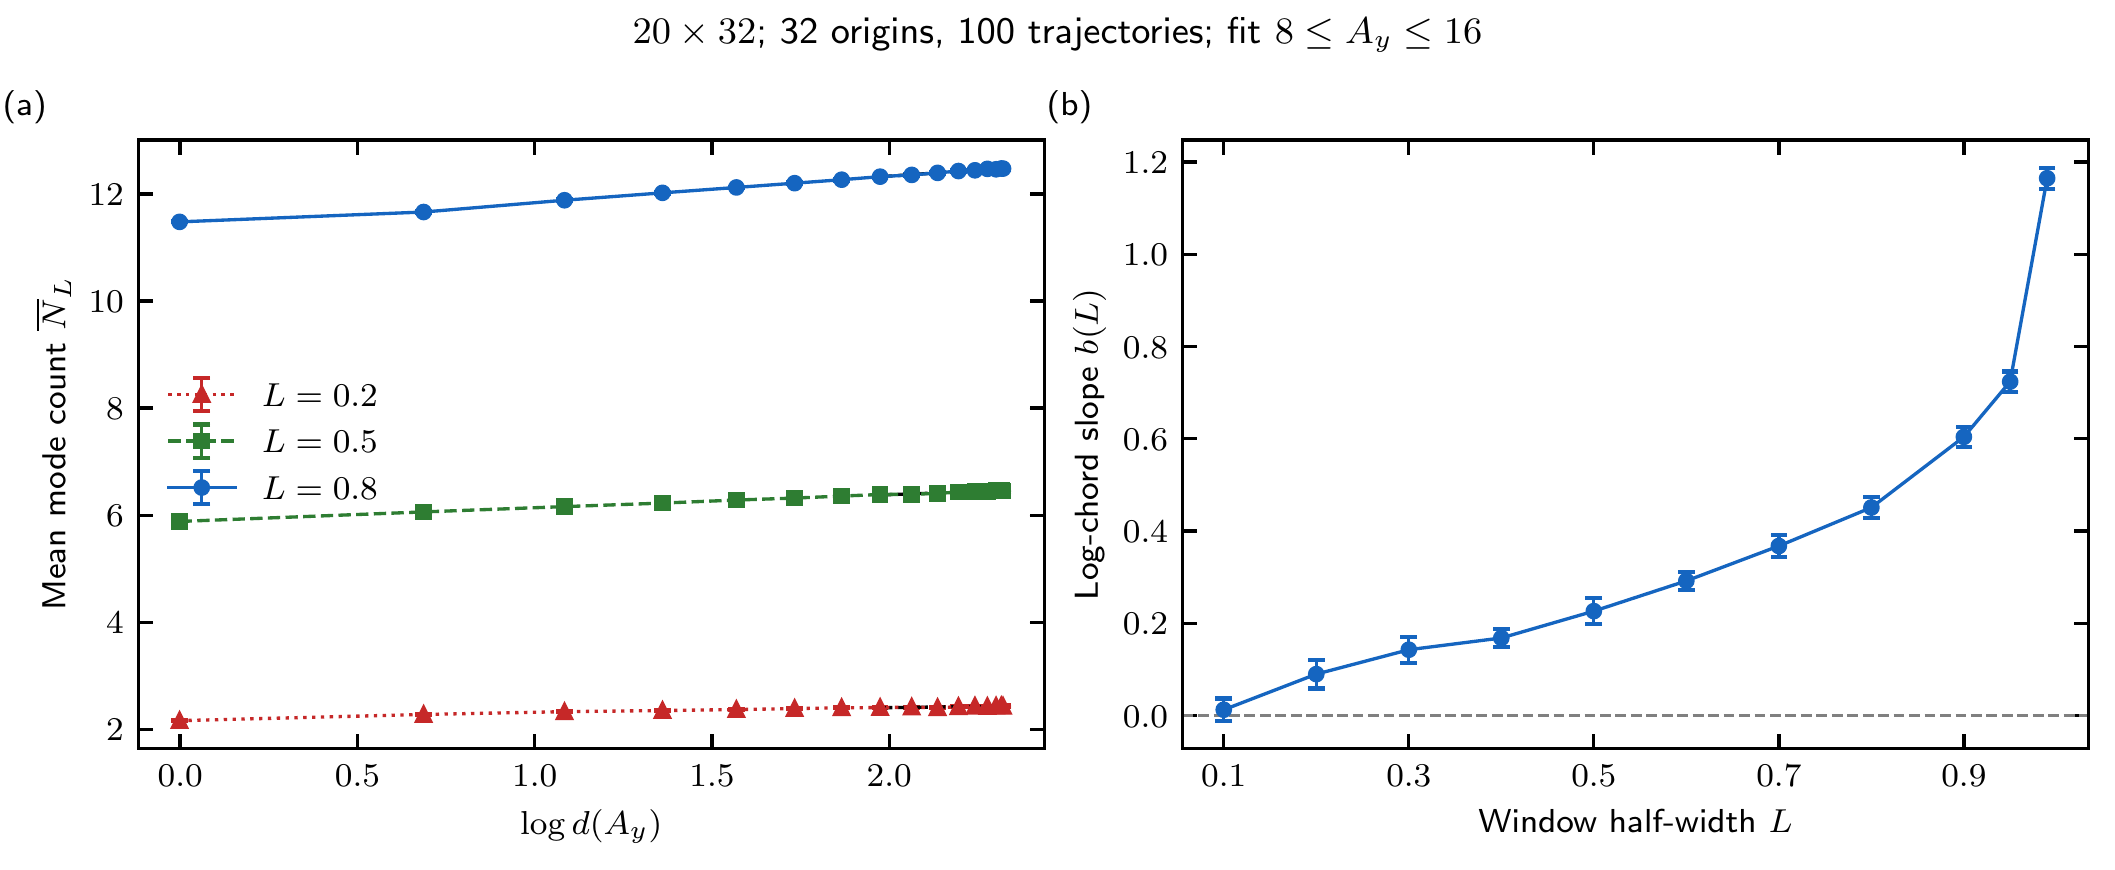

In [5]:
fig,axes=plt.subplots(1,2,figsize=(7.05,2.9))
styles=[('#c62828','^',':'),('#2e7d32','s','--'),('#1565c0','o','-')]
xx=np.linspace(log_chord[mask].min(),log_chord[mask].max(),150)
for L,(color,marker,style) in zip(DISPLAY_WINDOWS,styles):
    matches=np.flatnonzero(np.isclose(L_VALUES,L));
    if not len(matches):continue
    k=matches[0]
    axes[0].errorbar(log_chord,mean_counts[k],yerr=sem_counts[k],color=color,marker=marker,ls=style,
                     ms=3,lw=.8,capsize=2,label=r'$L=%.1f$'%L)
    axes[0].plot(xx,coefficients[k,0]+coefficients[k,1]*xx,color='black',ls='--',lw=.8)
axes[0].set(xlabel=r'$\log d(A_y)$',ylabel=r'Mean mode count $\overline N_L$')
axes[0].legend(frameon=False)
axes[1].errorbar(L_VALUES,coefficients[:,1],yerr=coefficient_sem[:,1],color='#1565c0',marker='o',ls='-',ms=3,capsize=2,lw=.8)
axes[1].axhline(0,color='gray',ls='--',lw=.7)
axes[1].set(xlabel=r'Window half-width $L$',ylabel=r'Log-chord slope $b(L)$',xticks=[.1,.3,.5,.7,.9])
for ax,letter in zip(axes,['(a)','(b)']):ax.text(-.15,1.04,letter,transform=ax.transAxes,fontweight='bold')
fig.suptitle(r'$20\times32$; 32 origins, 100 trajectories; fit $%d\leq A_y\leq%d$'%FIT_WIDTHS,fontsize=9)
export(fig,'window_dependence_summary')

## Standalone L = 0.9 fit
All 32 origins are averaged within each of the 100 trajectories. The figure shows subsystem widths 8–16, with a log-chord fit and trajectory SEM error bars.

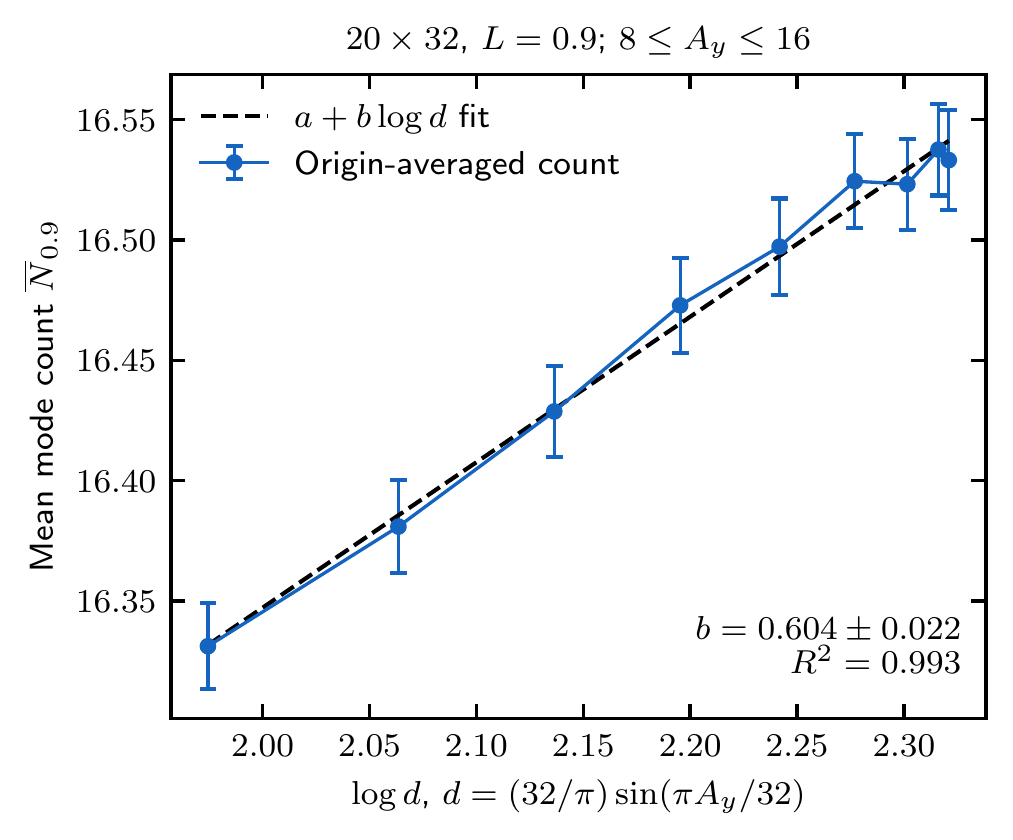

In [6]:
k=int(np.flatnonzero(np.isclose(L_VALUES,.9,rtol=0,atol=1e-14))[0])
fig,ax=plt.subplots(figsize=(3.375,2.8))
xx_single=np.linspace(log_chord[mask].min(),log_chord[mask].max(),150)
ax.errorbar(log_chord[mask],mean_counts[k,mask],yerr=sem_counts[k,mask],color='#1565c0',marker='o',ls='-',ms=3,capsize=2,lw=.8,label='Origin-averaged count')
ax.plot(xx_single,coefficients[k,0]+coefficients[k,1]*xx_single,color='black',ls='--',lw=1,label=r'$a+b\log d$ fit')
ax.set(xlabel=r'$\log d$, $d=(32/\pi)\sin(\pi A_y/32)$',ylabel=r'Mean mode count $\overline N_{0.9}$',
       title=r'$20\times32$, $L=0.9$; $%d\leq A_y\leq%d$'%FIT_WIDTHS)
ax.legend(frameon=False,loc='upper left',fontsize=8)
ax.text(.97,.06,r'$b=%.3f\pm%.3f$'%(coefficients[k,1],coefficient_sem[k,1])+'\n'+r'$R^2=%.3f$'%r_squared[k],transform=ax.transAxes,ha='right',va='bottom',fontsize=8)
export(fig,'mean_mode_count_L090')

## All fitted windows
Each panel zooms to the subsystem widths used in the fit. Vertical axes have independent limits so the small changes with chord length remain visible. Error bars are trajectory SEM. R-squared measures the mean curve only.

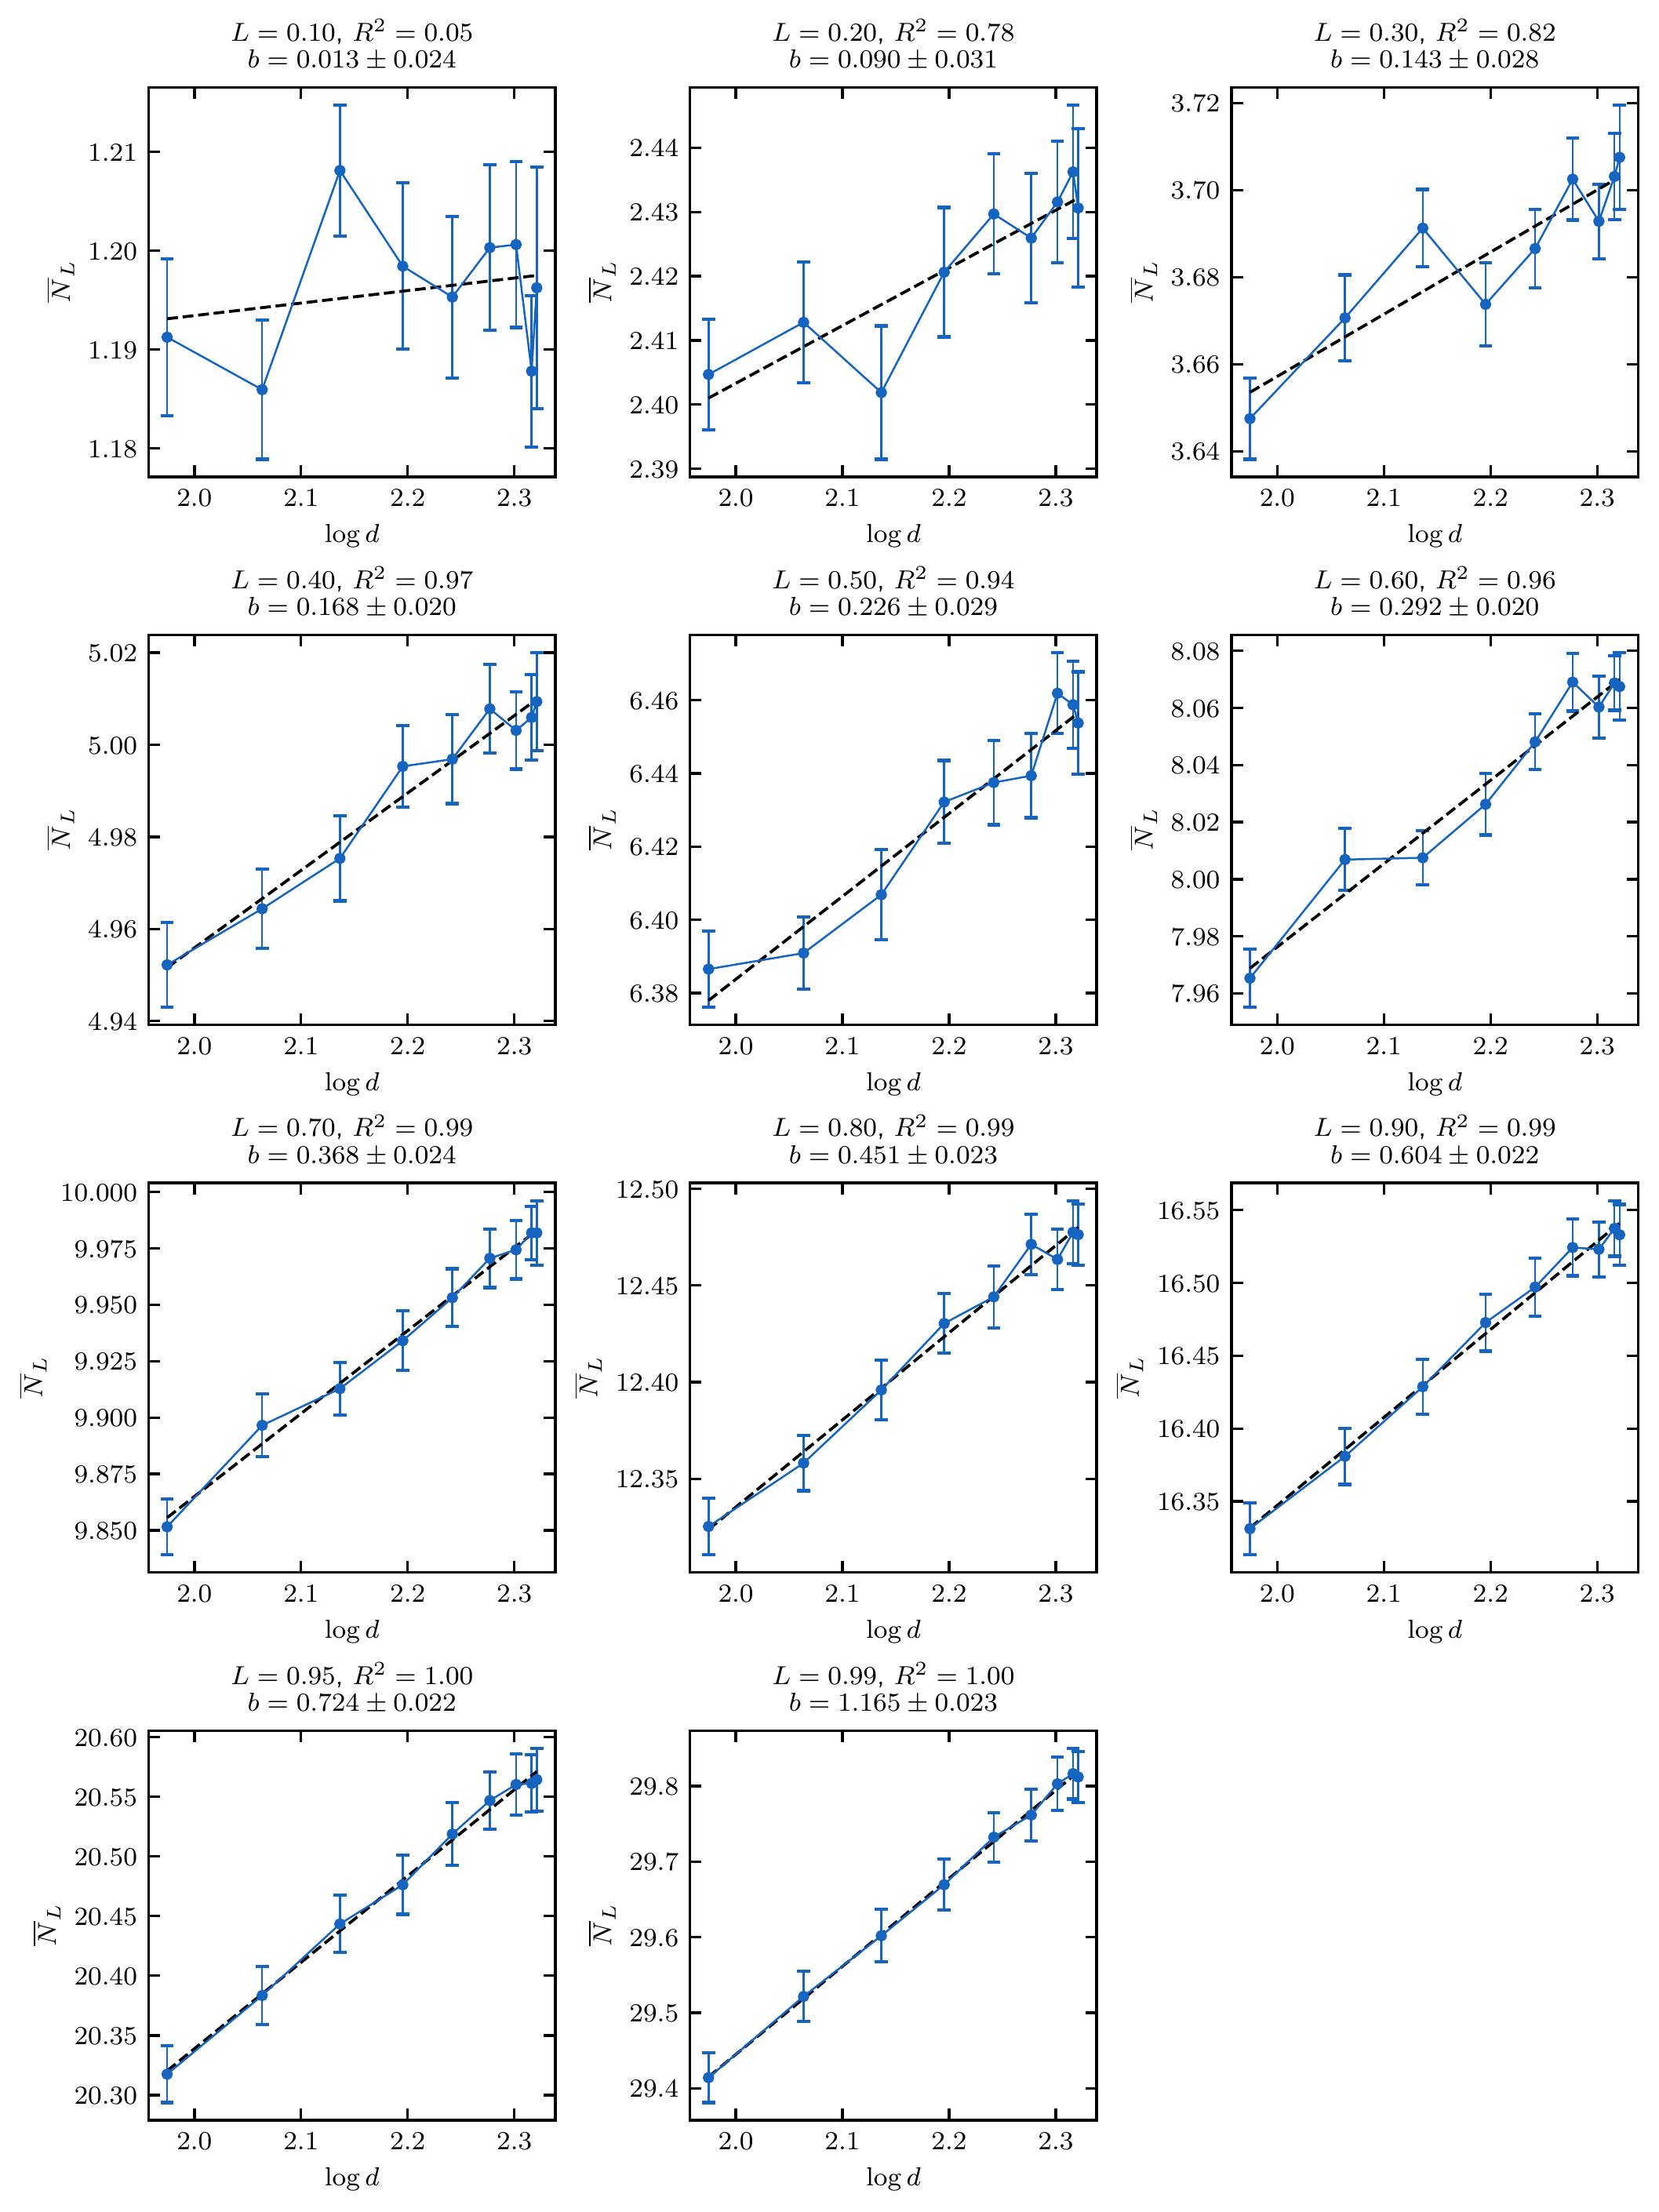

In [7]:
ncols=3;nrows=int(np.ceil(len(L_VALUES)/ncols))
fig,axes=plt.subplots(nrows,ncols,figsize=(7.05,2.35*nrows),squeeze=False)
for k,ax in enumerate(axes.flat):
    if k>=len(L_VALUES):ax.set_visible(False);continue
    ax.errorbar(log_chord[mask],mean_counts[k,mask],yerr=sem_counts[k,mask],color='#1565c0',marker='o',ls='-',ms=2.5,capsize=2,lw=.6)
    ax.plot(xx,coefficients[k,0]+coefficients[k,1]*xx,color='black',ls='--',lw=.9)
    ax.set_title(r'$L=%.2f$, $R^2=%.2f$'%(L_VALUES[k],r_squared[k])+'\n'+r'$b=%.3f\pm%.3f$'%(coefficients[k,1],coefficient_sem[k,1]),fontsize=8)
    ax.set(xlabel=r'$\log d$',ylabel=r'$\overline N_L$')
export(fig,'all_window_fits')

## Fit intercepts and residuals
Both fit coefficients vary with the spectral window. The residual RMS is in units of mean mode count and is provided alongside R-squared to avoid treating R-squared alone as evidence of a scaling law.

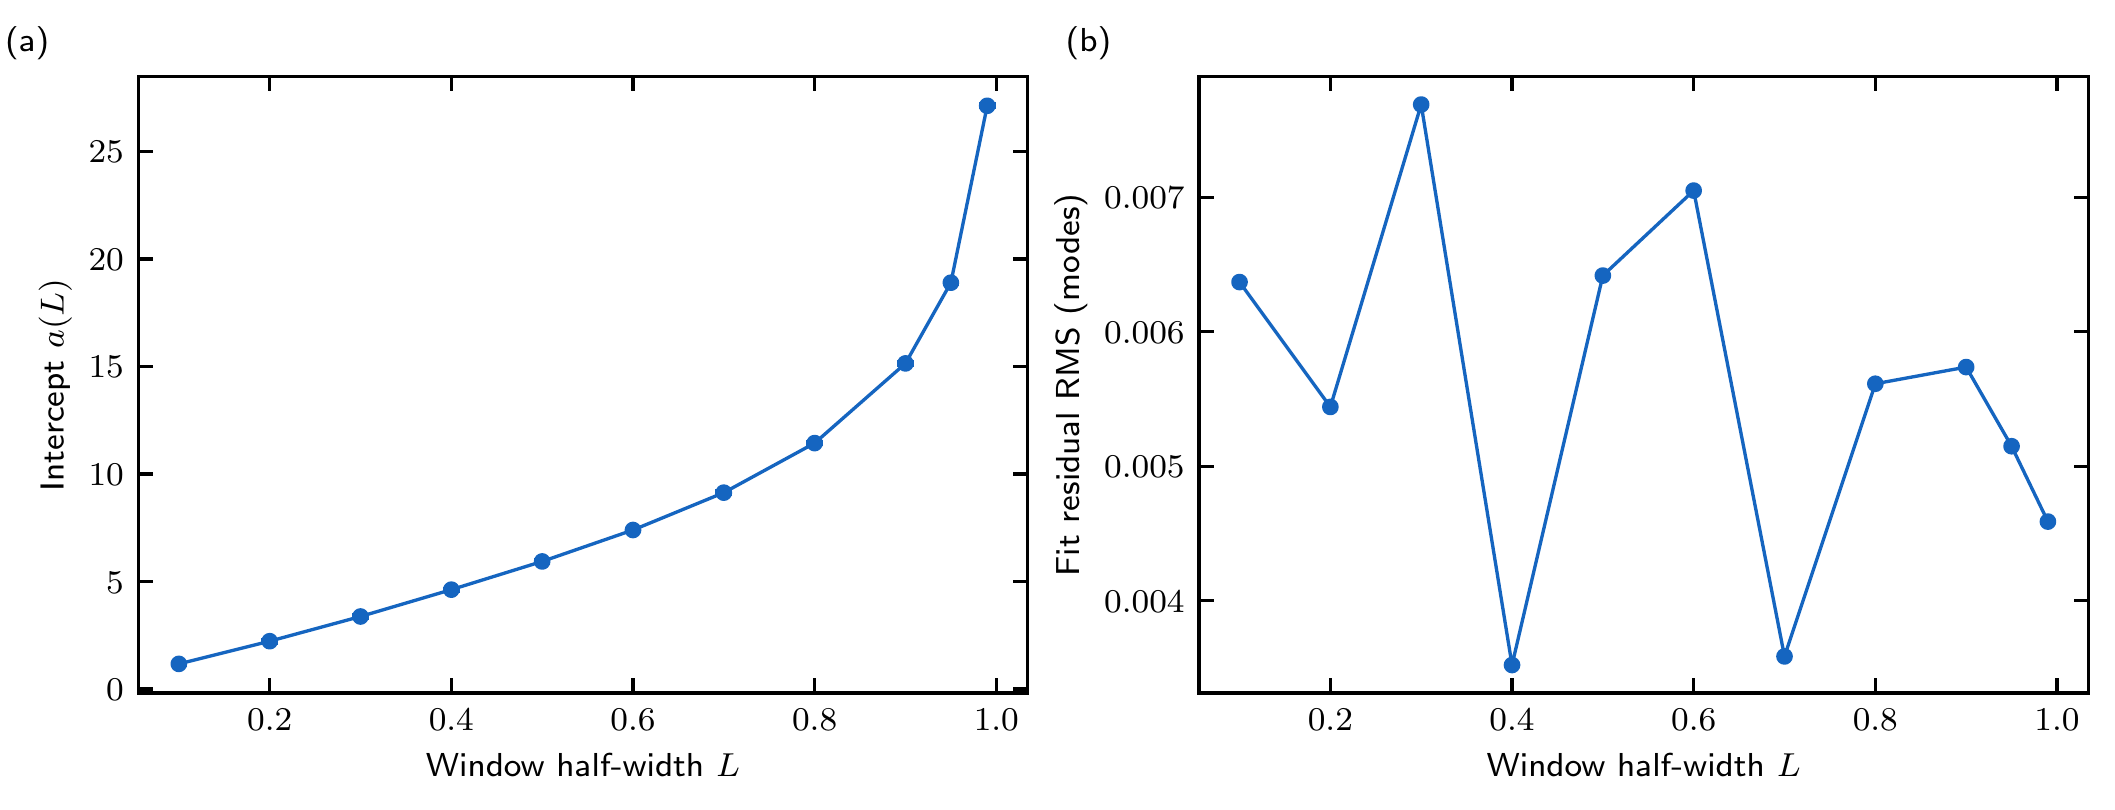

In [8]:
fig,axes=plt.subplots(1,2,figsize=(7.05,2.7))
axes[0].errorbar(L_VALUES,coefficients[:,0],yerr=coefficient_sem[:,0],color='#1565c0',marker='o',ls='-',ms=3,capsize=2,lw=.8)
axes[0].set(xlabel=r'Window half-width $L$',ylabel=r'Intercept $a(L)$')
axes[1].plot(L_VALUES,fits.residual_rms,color='#1565c0',marker='o',ms=3,lw=.8)
axes[1].set(xlabel=r'Window half-width $L$',ylabel='Fit residual RMS (modes)')
for ax,letter in zip(axes,['(a)','(b)']):ax.text(-.15,1.04,letter,transform=ax.transAxes,fontweight='bold')
export(fig,'window_fit_diagnostics')

Caption: S=100 independent hard-wall trajectories at Nx=20, Ny=32, alpha1=1, alpha2=30, nshell=1, initialized as pure states with the exterior prepared as a product frame; saved endpoints at cycle 64. Each subsystem contains all x, both orbitals, and Ay consecutive periodic y rows. Count centered covariance eigenvalues in [-L,L] per origin, average the 32 origins inside each trajectory, then average trajectories. No normalization by mode number is applied. Error bars are one trajectory SEM. Fits use Ay=8–16 and natural log chord length; full cross-width correlations are retained in coefficient uncertainties. Different windows are correlated because they use the same trajectories.

## Numerical diagnostics and completion

In [9]:
print(json.dumps(checks,indent=2))
print(fits.to_string(index=False))
report='# Mean mode count: spectral-window scan\n\n'+json.dumps(config,indent=2)+'\n\n'
report+='Fit model: mean N_L = a(L) + b(L) log[(32/pi) sin(pi Ay/32)]. Coefficient uncertainties are SEMs of fits to the 100 trajectory-level origin averages. All fits are descriptive, with correlated widths and windows.\n\n'
report+=fits.to_string(index=False)+'\n\n'
report+='Outputs: mean_mode_counts.csv; window_fit_summary.csv; window_scan_statistics.npz (counts, trajectory averages, coefficients and joint covariance); input_provenance.json; window_scan_diagnostics.json; four PDF/PNG figure pairs, including the standalone L=0.9 fit. The validated spectrum cache stays in the adjacent source directory.\n'
(OUT/'README.md').write_text(report)
print('Completed window scan; L_VALUES and FIT_WIDTHS remain editable.')

{
  "raw_min": -1.000000000000013,
  "raw_max": 1.0000000000000417,
  "count_monotonic_in_L": true,
  "half_width_complement_counts_equal": true,
  "independent_trajectories": 100,
  "coefficient_covariance_flatten_order": "window, then [intercept,slope]",
  "L05_max_count_difference": 0.0,
  "L05_previous_slope_difference": 4.163336342344337e-16,
  "L05_previous_slope_sem_difference": 3.469446951953614e-18
}
   L  intercept  intercept_sem    slope  slope_sem  R_squared  residual_rms  max_abs_residual  fit_min_width  fit_max_width
0.10   1.168112       0.052458 0.012662   0.024360   0.049902      0.006370          0.012961              8             16
0.20   2.223546       0.068098 0.089883   0.031022   0.783904      0.005441          0.013701              8             16
0.30   3.371655       0.061568 0.142769   0.027968   0.820814      0.007690          0.014578              8             16
0.40   4.619438       0.044370 0.168220   0.020008   0.968093      0.003521          0.0065